In [9]:
# Clean previous CUDA installations
!apt-get -y --purge remove cuda*
!apt-get -y --purge remove nvidia*
!rm -rf /usr/local/cuda*

# Install build tools
!apt-get install -y --no-install-recommends build-essential curl git gnupg2 lsb-release wget

# Setup environment
import os
os.environ['DEBIAN_FRONTEND'] = 'noninteractive'

# Download and install CUDA 12.2
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64/cuda-ubuntu2004.pin
!mv cuda-ubuntu2004.pin /etc/apt/preferences.d/cuda-repository-pin-600
!wget https://developer.download.nvidia.com/compute/cuda/12.2.2/local_installers/cuda-repo-ubuntu2004-12-2-local_12.2.2-470.161.03-1_amd64.deb
!dpkg -i cuda-repo-ubuntu2004-12-2-local_12.2.2-470.161.03-1_amd64.deb
!apt-key add /var/cuda-repo-ubuntu2004-12-2-local/7fa2af80.pub
!apt-get update
!apt-get -y install cuda-12-2

# Verify installation
!nvcc --version

# Set environment variables
os.environ["CUDA_HOME"] = "/usr/local/cuda-12.2"
os.environ["PATH"] = "/usr/local/cuda-12.2/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = "/usr/local/cuda-12.2/lib64:" + os.environ.get("LD_LIBRARY_PATH", "")

# Install nvcc4jupyter
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%reload_ext nvcc4jupyter

# Final verification
!nvcc --version
!nvidia-smi

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'cuda-toolkit-12-4-config-common' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-11-0' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-11-1' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-11-7' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-11-8' for glob 'cuda*'
Note, selecting 'cuda-toolkit-12-5-config-common' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-0' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-1' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-2' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-3' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-4' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-5' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-6' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-8' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-12-9' for glob 'cuda*'
Note, selecting 'cuda-cudart-dev-13-0' fo

In [10]:
%%writefile enhanced_box_blur.cu
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include "lodepng.h"

// CUDA kernel for 3x3 box blur with debugging
__global__ void boxBlurKernel(unsigned char* inputImage, unsigned char* outputImage,
                             int width, int height) {
    // Calculate thread index
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // Calculate pixel coordinates
    int x = idx % width;
    int y = idx / width;

    // Check bounds
    if (x >= width || y >= height) return;

    // Calculate pixel index in RGBA format (4 bytes per pixel)
    int pixelIdx = (y * width + x) * 4;

    // Initialize sum for RGB channels
    int sumR = 0, sumG = 0, sumB = 0;
    int count = 0;

    // Apply 3x3 box blur
    for (int dy = -1; dy <= 1; dy++) {
        for (int dx = -1; dx <= 1; dx++) {
            int nx = x + dx;
            int ny = y + dy;

            // Check if neighbor is within image bounds
            if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                int neighborIdx = (ny * width + nx) * 4;
                sumR += inputImage[neighborIdx];     // Red
                sumG += inputImage[neighborIdx + 1]; // Green
                sumB += inputImage[neighborIdx + 2]; // Blue
                count++;
            }
        }
    }

    // Calculate average and store result
    outputImage[pixelIdx] = sumR / count;     // Red
    outputImage[pixelIdx + 1] = sumG / count; // Green
    outputImage[pixelIdx + 2] = sumB / count; // Blue
    outputImage[pixelIdx + 3] = inputImage[pixelIdx + 3]; // Alpha (unchanged)
}

// CUDA kernel for multiple blur iterations
__global__ void multipleBlurKernel(unsigned char* inputImage, unsigned char* outputImage,
                                  int width, int height, int iterations) {
    // Calculate thread index
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // Calculate pixel coordinates
    int x = idx % width;
    int y = idx / width;

    // Check bounds
    if (x >= width || y >= height) return;

    // Calculate pixel index in RGBA format (4 bytes per pixel)
    int pixelIdx = (y * width + x) * 4;

    // Initialize with original values
    int currentR = inputImage[pixelIdx];
    int currentG = inputImage[pixelIdx + 1];
    int currentB = inputImage[pixelIdx + 2];

    // Apply multiple blur iterations
    for (int iter = 0; iter < iterations; iter++) {
        int sumR = 0, sumG = 0, sumB = 0;
        int count = 0;

        // Apply 3x3 box blur
        for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
                int nx = x + dx;
                int ny = y + dy;

                // Check if neighbor is within image bounds
                if (nx >= 0 && nx < width && ny >= 0 && ny < height) {
                    int neighborIdx = (ny * width + nx) * 4;
                    sumR += inputImage[neighborIdx];     // Red
                    sumG += inputImage[neighborIdx + 1]; // Green
                    sumB += inputImage[neighborIdx + 2]; // Blue
                    count++;
                }
            }
        }

        // Update current values for next iteration
        currentR = sumR / count;
        currentG = sumG / count;
        currentB = sumB / count;
    }

    // Store final result
    outputImage[pixelIdx] = currentR;     // Red
    outputImage[pixelIdx + 1] = currentG; // Green
    outputImage[pixelIdx + 2] = currentB; // Blue
    outputImage[pixelIdx + 3] = inputImage[pixelIdx + 3]; // Alpha (unchanged)
}

int main() {
    // Step 1: Reading in an image file
    printf("Step 1: Reading PNG image...\n");

    unsigned char* image;
    unsigned int width, height;

    // Decode PNG image
    unsigned error = lodepng_decode32_file(&image, &width, &height, "/content/image.png");
    if (error) {
        printf("Error %u: %s\n", error, lodepng_error_text(error));
        return 1;
    }

    printf("Image loaded successfully: %dx%d pixels\n", width, height);

    // Calculate total number of pixels
    int totalPixels = width * height;
    int imageSize = totalPixels * 4; // 4 bytes per pixel (RGBA)

    // Step 2: Allocating GPU memory
    printf("Step 2: Allocating GPU memory...\n");

    unsigned char* d_inputImage;
    unsigned char* d_outputImage;
    unsigned char* d_tempImage;

    // Allocate memory on GPU
    cudaMalloc(&d_inputImage, imageSize);
    cudaMalloc(&d_outputImage, imageSize);
    cudaMalloc(&d_tempImage, imageSize);

    // Copy input image to GPU
    cudaMemcpy(d_inputImage, image, imageSize, cudaMemcpyHostToDevice);

    printf("GPU memory allocated: %d bytes\n", imageSize);

    // Step 3: Applying Box filter on image in kernel function
    printf("Step 3: Applying 3x3 box blur filter...\n");

    // Calculate grid and block dimensions
    int threadsPerBlock = 256;
    int blocksPerGrid = (totalPixels + threadsPerBlock - 1) / threadsPerBlock;

    printf("Launching kernel with %d blocks, %d threads per block\n", blocksPerGrid, threadsPerBlock);

    // Apply single blur first
    boxBlurKernel<<<blocksPerGrid, threadsPerBlock>>>(d_inputImage, d_outputImage, width, height);

    // Wait for kernel to complete
    cudaDeviceSynchronize();

    // Check for kernel errors
    cudaError_t kernelError = cudaGetLastError();
    if (kernelError != cudaSuccess) {
        printf("Kernel launch failed: %s\n", cudaGetErrorString(kernelError));
        return 1;
    }

    printf("Single box blur filter applied successfully\n");

    // Apply multiple blur iterations for stronger effect
    printf("Applying multiple blur iterations for stronger effect...\n");
    int blurIterations = 3; // Apply blur 3 times for more noticeable effect

    multipleBlurKernel<<<blocksPerGrid, threadsPerBlock>>>(d_inputImage, d_outputImage, width, height, blurIterations);

    cudaDeviceSynchronize();

    kernelError = cudaGetLastError();
    if (kernelError != cudaSuccess) {
        printf("Multiple blur kernel launch failed: %s\n", cudaGetErrorString(kernelError));
        return 1;
    }

    printf("Multiple blur iterations (%d) applied successfully\n", blurIterations);

    // Step 4: Returning blurred image data from GPU to CPU
    printf("Step 4: Transferring blurred image from GPU to CPU...\n");

    unsigned char* blurredImage = (unsigned char*)malloc(imageSize);
    cudaMemcpy(blurredImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost);

    printf("Image data transferred back to CPU\n");

    // Step 5: Outputting the correct image with Box Blur applied
    printf("Step 5: Saving blurred image...\n");

    // Encode and save the blurred image
    unsigned error2 = lodepng_encode32_file("/content/enhanced_blurred_image.png", blurredImage, width, height);
    if (error2) {
        printf("Error %u: %s\n", error2, lodepng_error_text(error2));
        return 1;
    }

    printf("Enhanced blurred image saved as '/content/enhanced_blurred_image.png'\n");

    // Also save a single-blur version for comparison
    cudaMemcpy(blurredImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost);
    boxBlurKernel<<<blocksPerGrid, threadsPerBlock>>>(d_inputImage, d_outputImage, width, height);
    cudaDeviceSynchronize();
    cudaMemcpy(blurredImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost);

    lodepng_encode32_file("/content/single_blur_image.png", blurredImage, width, height);
    printf("Single blur image saved as '/content/single_blur_image.png'\n");

    // Cleanup
    printf("Cleaning up memory...\n");

    // Free GPU memory
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);
    cudaFree(d_tempImage);

    // Free CPU memory
    free(image);
    free(blurredImage);

    printf("Enhanced box blur processing completed successfully!\n");
    return 0;
}

Overwriting enhanced_box_blur.cu


In [11]:
# Compile the program
!nvcc -o enhanced_box_blur enhanced_box_blur.cu lodepng.o

# Run the program
!./enhanced_box_blur

/bin/bash: line 1: nvcc: command not found
Step 1: Reading PNG image...
Image loaded successfully: 1232x1280 pixels
Step 2: Allocating GPU memory...
GPU memory allocated: 6307840 bytes
Step 3: Applying 3x3 box blur filter...
Launching kernel with 6160 blocks, 256 threads per block
Single box blur filter applied successfully
Applying multiple blur iterations for stronger effect...
Multiple blur iterations (3) applied successfully
Step 4: Transferring blurred image from GPU to CPU...
Image data transferred back to CPU
Step 5: Saving blurred image...
Enhanced blurred image saved as '/content/enhanced_blurred_image.png'
Single blur image saved as '/content/single_blur_image.png'
Cleaning up memory...
Enhanced box blur processing completed successfully!


In [12]:
# Execute the program
!./box_blur

Step 1: Reading PNG image...
Image loaded successfully: 1232x1280 pixels
Step 2: Allocating GPU memory...
GPU memory allocated: 6307840 bytes
Step 3: Applying 3x3 box blur filter...
Launching kernel with 6160 blocks, 256 threads per block
Box blur filter applied successfully
Step 4: Transferring blurred image from GPU to CPU...
Image data transferred back to CPU
Step 5: Saving blurred image...
Blurred image saved as '/content/blurred_image.png'
Cleaning up memory...
Box blur processing completed successfully!


=== IMAGE COMPARISON ===
Original Image:


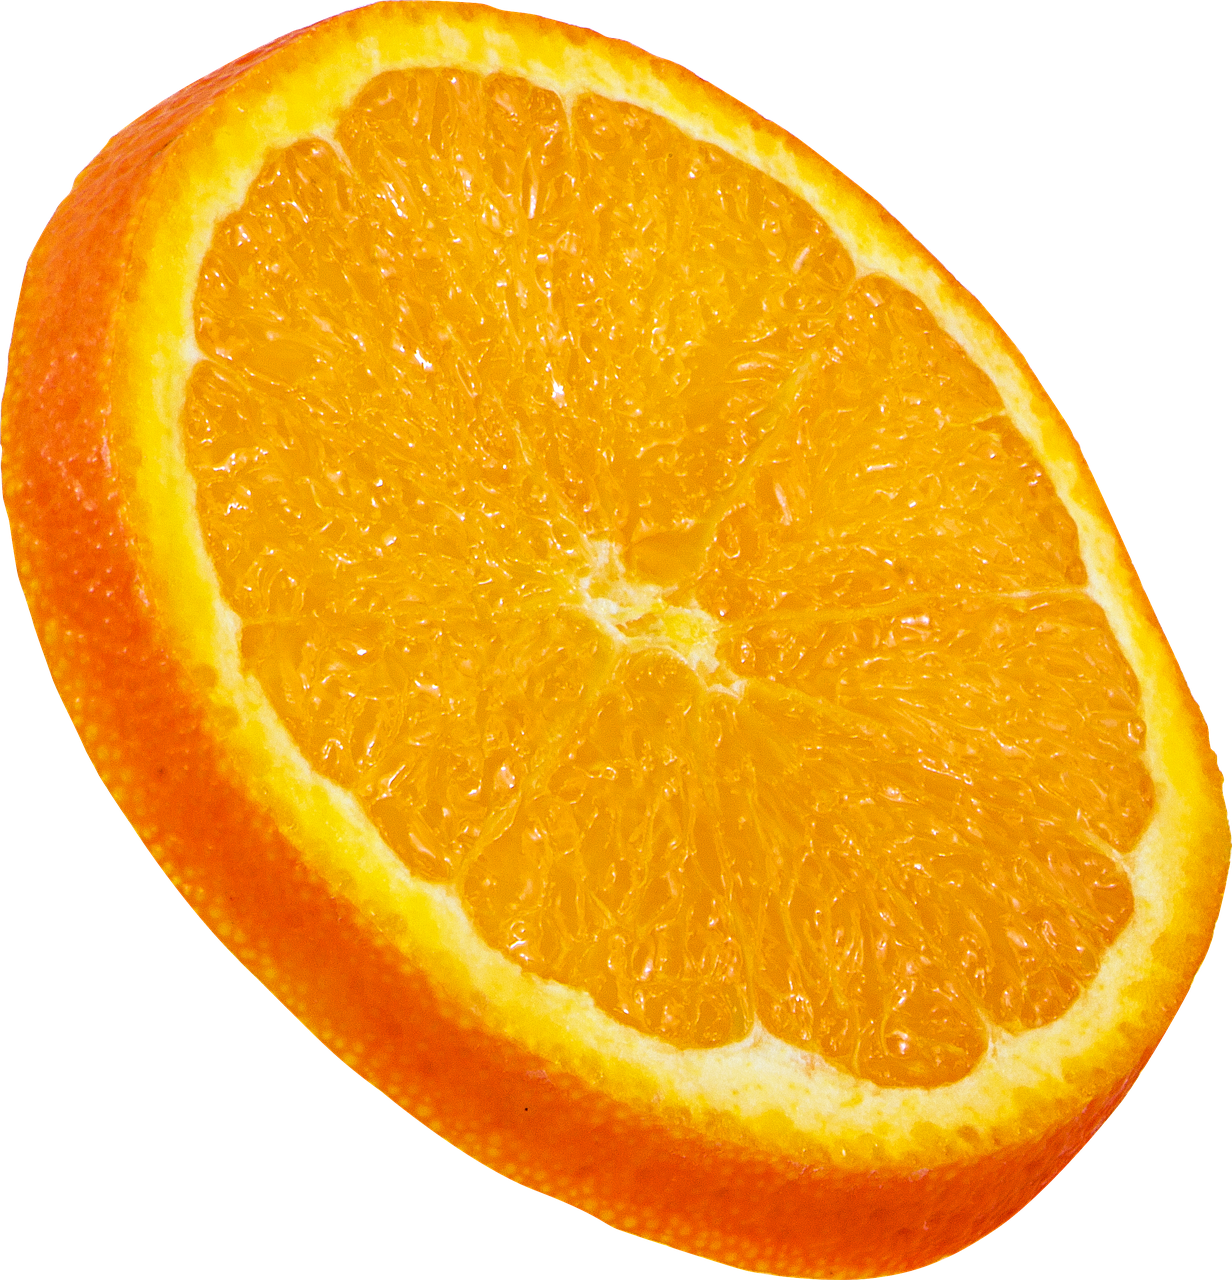

Single Blur (Original Implementation):


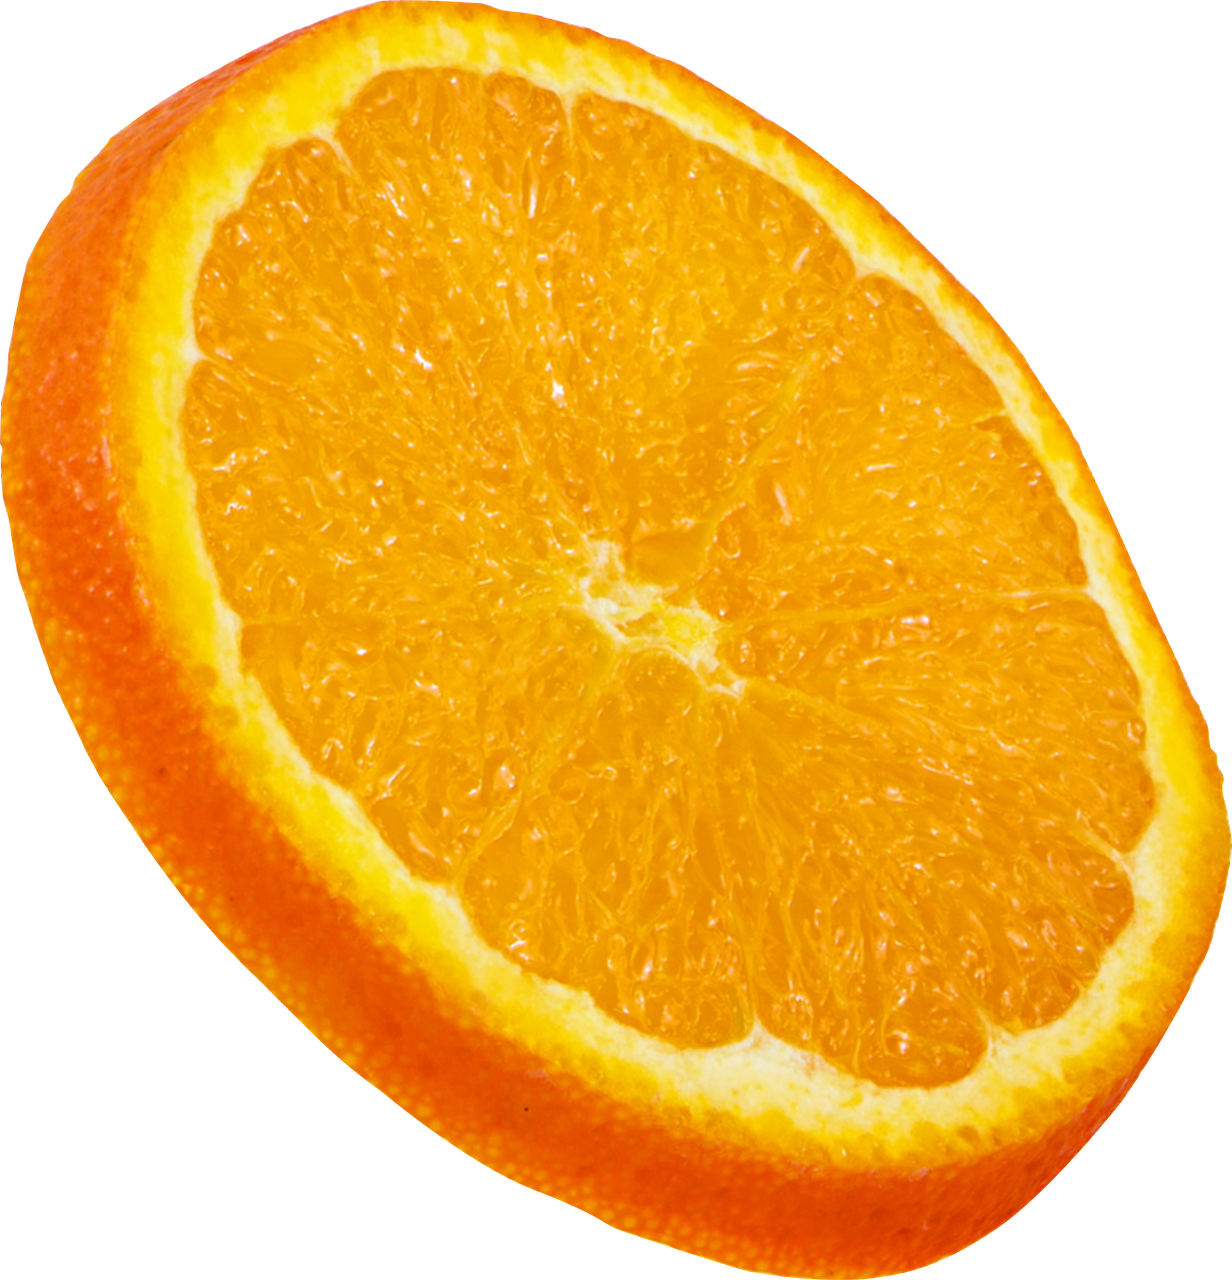

Enhanced Multiple Blur:


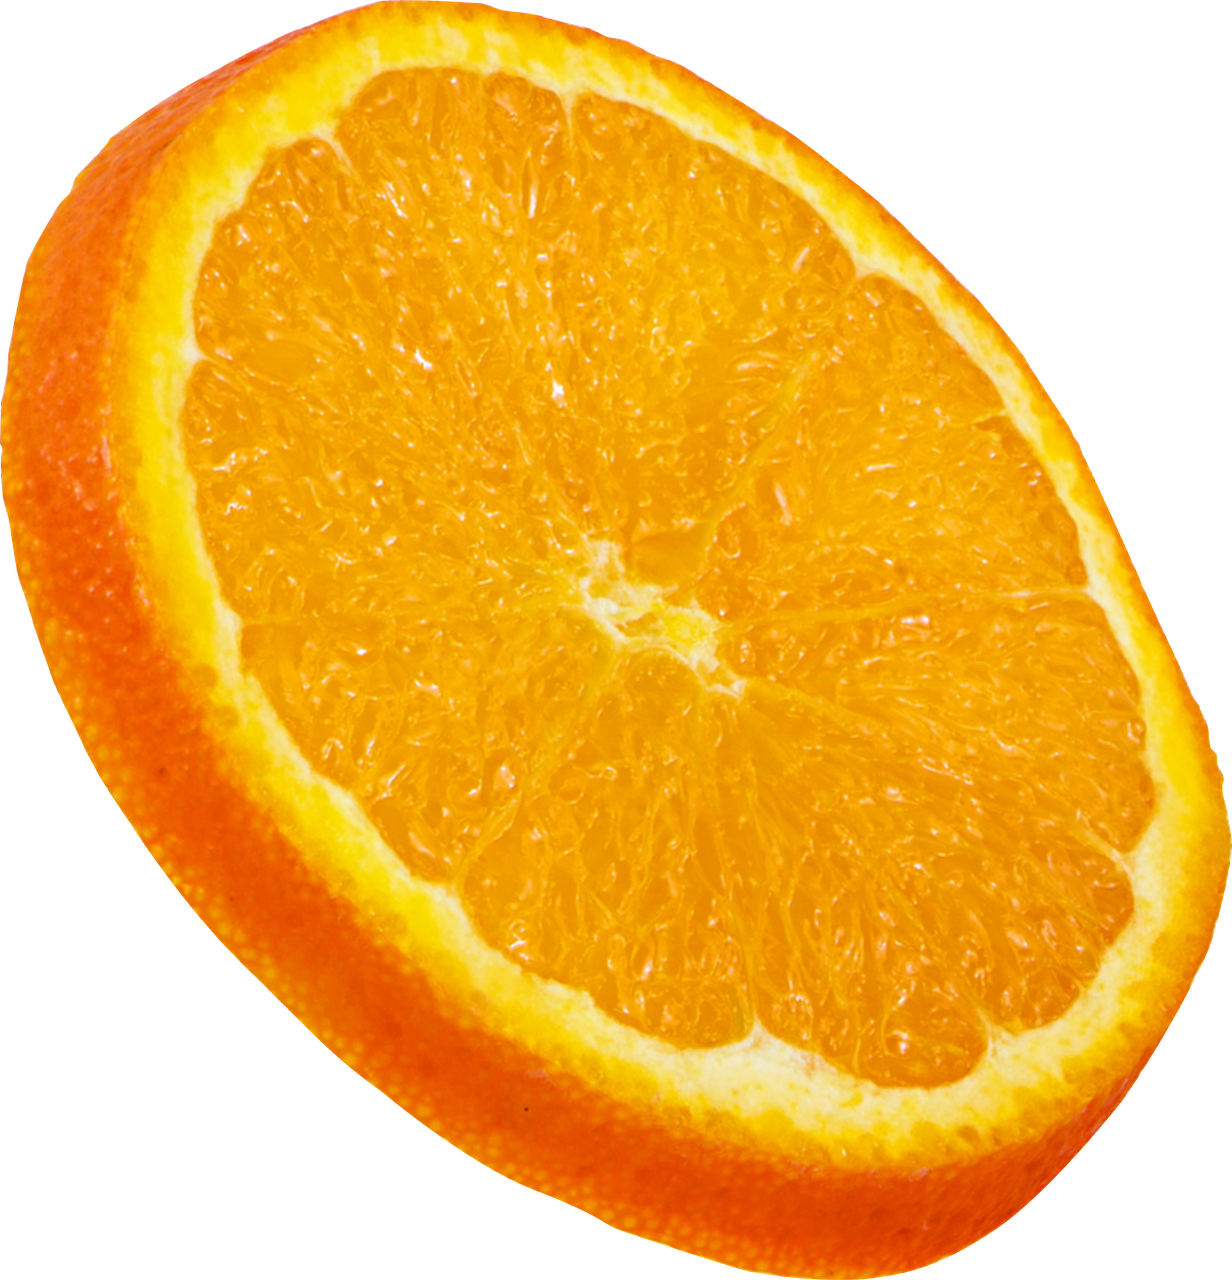

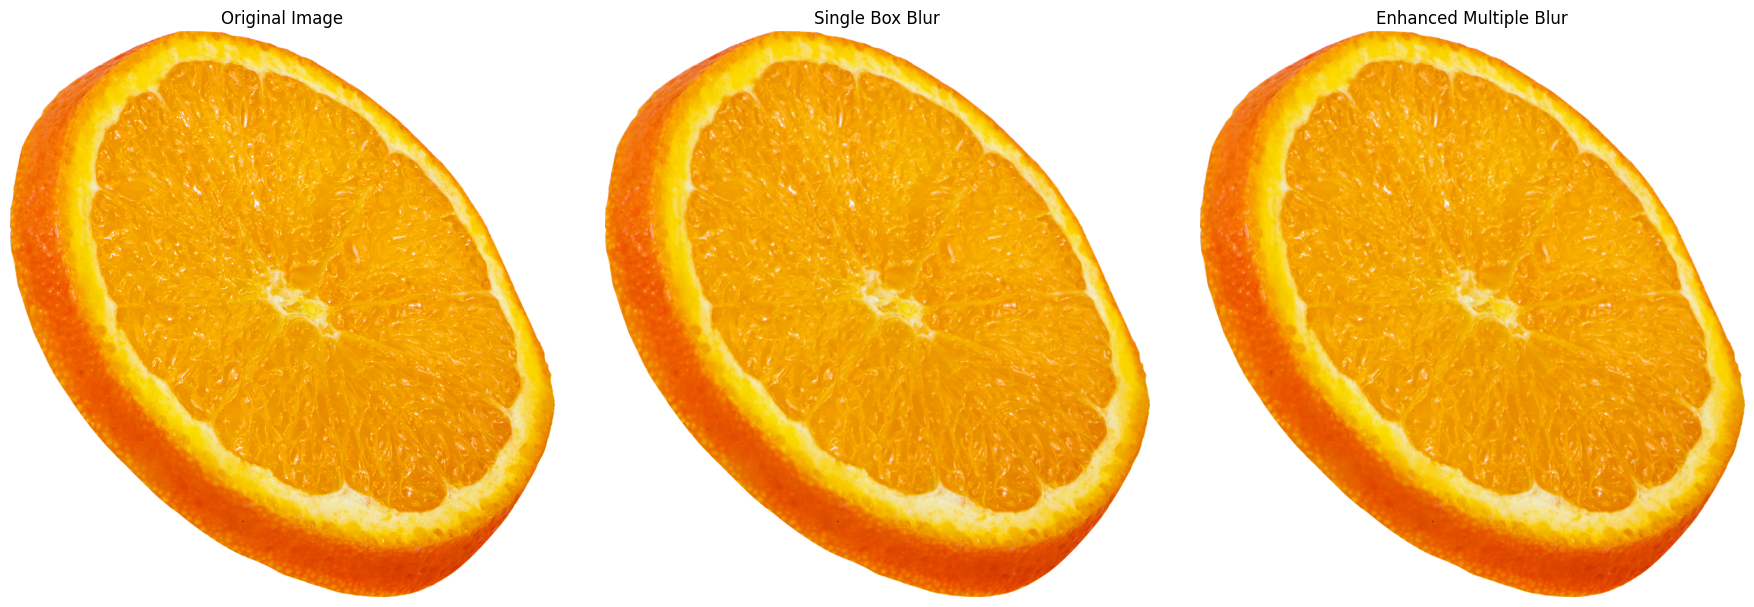


=== BLUR ANALYSIS ===
Average pixel difference (Single Blur): 0.01
Average pixel difference (Enhanced Blur): 0.01
Max pixel difference (Single Blur): 0.89
Max pixel difference (Enhanced Blur): 0.89


In [13]:
# Display all images for comparison
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("=== IMAGE COMPARISON ===")
print("Original Image:")
display(Image('/content/image.png'))

print("Single Blur (Original Implementation):")
display(Image('/content/single_blur_image.png'))

print("Enhanced Multiple Blur:")
display(Image('/content/enhanced_blurred_image.png'))

# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
img1 = mpimg.imread('/content/image.png')
axes[0].imshow(img1)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Single blur
img2 = mpimg.imread('/content/single_blur_image.png')
axes[1].imshow(img2)
axes[1].set_title('Single Box Blur')
axes[1].axis('off')

# Enhanced blur
img3 = mpimg.imread('/content/enhanced_blurred_image.png')
axes[2].imshow(img3)
axes[2].set_title('Enhanced Multiple Blur')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print pixel difference analysis
import numpy as np

# Calculate differences
diff_single = np.abs(img1.astype(float) - img2.astype(float))
diff_enhanced = np.abs(img1.astype(float) - img3.astype(float))

print(f"\n=== BLUR ANALYSIS ===")
print(f"Average pixel difference (Single Blur): {np.mean(diff_single):.2f}")
print(f"Average pixel difference (Enhanced Blur): {np.mean(diff_enhanced):.2f}")
print(f"Max pixel difference (Single Blur): {np.max(diff_single):.2f}")
print(f"Max pixel difference (Enhanced Blur): {np.max(diff_enhanced):.2f}")